# Deep Learning Practicals: DCGAN and VAE

## Part 1 — Training a DCGAN on Fashion-MNIST
This practical implements a Deep Convolutional Generative Adversarial Network (DCGAN) using PyTorch.

## Part 2 — Variational Autoencoder (VAE) Demo
This practical implements a normal Autoencoder followed by a Variational Autoencoder on MNIST.

**Note:** Run the notebook from top to bottom. Training can take time, especially without a GPU.


# Part 1: DCGAN on Fashion-MNIST

### Requirements covered
- Import libraries
- Set basic parameters
- Use a fixed/hardcoded noise vector
- Load Fashion-MNIST
- Normalize images to -1 to +1
- Use Tanh in the Generator's final layer
- Generate an image before training
- Build Generator using transposed convolutions
- Build Discriminator using convolution layers and Sigmoid
- Binary Cross-Entropy loss
- Train Generator and Discriminator for 25 epochs
- Save a 4 × 4 generated image grid after every 5 epochs
- Record both losses
- Plot Generator and Discriminator losses
- Answer the four analysis questions


In [1]:
# 1. Import libraries

import os
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

print("PyTorch:", torch.__version__)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

os.makedirs("dcgan_generated", exist_ok=True)


PyTorch: 2.11.0+cu128
Device: cuda


In [2]:
# 2. Set basic parameters

BATCH_SIZE = 128
IMAGE_SIZE = 64
CHANNELS = 1
LATENT_DIM = 100

G_FILTERS = 64
D_FILTERS = 64

EPOCHS = 25
LR = 0.0002
BETA1 = 0.5

print("Batch size:", BATCH_SIZE)
print("Image size:", IMAGE_SIZE)
print("Latent dimension:", LATENT_DIM)
print("Epochs:", EPOCHS)


Batch size: 128
Image size: 64
Latent dimension: 100
Epochs: 25


In [3]:
# 3. Hardcoded/fixed noise vector

# A fixed noise vector is kept unchanged throughout training.
# This lets us compare how the Generator improves over time.

fixed_noise = torch.randn(16, LATENT_DIM, 1, 1, device=device)

print("Fixed noise shape:", fixed_noise.shape)


Fixed noise shape: torch.Size([16, 100, 1, 1])


In [4]:
# 4. Load Fashion-MNIST and normalize images to -1 to +1

transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

fashion_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

fashion_loader = DataLoader(
    fashion_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

print("Training samples:", len(fashion_dataset))


100%|██████████| 26.4M/26.4M [00:01<00:00, 13.6MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 202kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.77MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 25.3MB/s]

Training samples: 60000


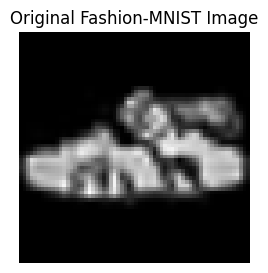

In [5]:
# 5. Display an original Fashion-MNIST image

real_batch, labels = next(iter(fashion_loader))
original_image = real_batch[0]

# Convert [-1, 1] back to [0, 1] for display
display_image = (original_image + 1) / 2

plt.figure(figsize=(3, 3))
plt.imshow(display_image.squeeze(), cmap="gray")
plt.title("Original Fashion-MNIST Image")
plt.axis("off")
plt.show()


## 6. Build the Generator

The Generator starts with random noise and uses **transposed convolution** layers to increase the image size:

`100 × 1 × 1 → 512 × 4 × 4 → 256 × 8 × 8 → 128 × 16 × 16 → 64 × 32 × 32 → 1 × 64 × 64`

The final **Tanh** activation produces pixel values in the range **-1 to +1**, matching the normalized training images.


In [6]:
# 7. Generator

class Generator(nn.Module):
    def __init__(self, z_dim=100, filters=64, channels=1):
        super().__init__()

        self.model = nn.Sequential(
            # Noise: 100 x 1 x 1 -> 512 x 4 x 4
            nn.ConvTranspose2d(z_dim, filters * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(filters * 8),
            nn.ReLU(True),

            # 4 x 4 -> 8 x 8
            nn.ConvTranspose2d(filters * 8, filters * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(filters * 4),
            nn.ReLU(True),

            # 8 x 8 -> 16 x 16
            nn.ConvTranspose2d(filters * 4, filters * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(filters * 2),
            nn.ReLU(True),

            # 16 x 16 -> 32 x 32
            nn.ConvTranspose2d(filters * 2, filters, 4, 2, 1, bias=False),
            nn.BatchNorm2d(filters),
            nn.ReLU(True),

            # 32 x 32 -> 64 x 64
            nn.ConvTranspose2d(filters, channels, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, x):
        return self.model(x)


G = Generator(LATENT_DIM, G_FILTERS, CHANNELS).to(device)

print(G)


Generator(
  (model): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (13): Tanh()
  )
)

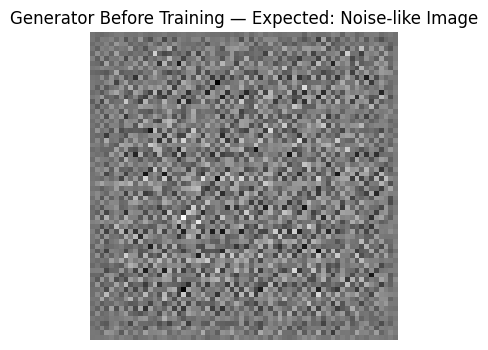

Generated image shape: torch.Size([1, 64, 64])


In [7]:
# 8. Test the Generator BEFORE training

G.eval()

with torch.no_grad():
    test_fake = G(fixed_noise)

plt.figure(figsize=(4, 4))
plt.imshow(((test_fake[0] + 1) / 2).squeeze().cpu(), cmap="gray")
plt.title("Generator Before Training — Expected: Noise-like Image")
plt.axis("off")
plt.show()

print("Generated image shape:", test_fake[0].shape)


## 9. Build the Discriminator

The Discriminator receives an image and predicts:

- **1 = real**
- **0 = fake**

It uses convolution layers to extract image features and a final **Sigmoid** activation to output a probability between 0 and 1.


In [8]:
# 10. Discriminator

class Discriminator(nn.Module):
    def __init__(self, channels=1, filters=64):
        super().__init__()

        self.model = nn.Sequential(
            # 64 x 64 -> 32 x 32
            nn.Conv2d(channels, filters, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            # 32 x 32 -> 16 x 16
            nn.Conv2d(filters, filters * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(filters * 2),
            nn.LeakyReLU(0.2, inplace=True),

            # 16 x 16 -> 8 x 8
            nn.Conv2d(filters * 2, filters * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(filters * 4),
            nn.LeakyReLU(0.2, inplace=True),

            # 8 x 8 -> 4 x 4
            nn.Conv2d(filters * 4, filters * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(filters * 8),
            nn.LeakyReLU(0.2, inplace=True),

            # 4 x 4 -> 1 x 1
            nn.Conv2d(filters * 8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x).view(-1)


D = Discriminator(CHANNELS, D_FILTERS).to(device)

print(D)


Discriminator(
  (model): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (9): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
    (11): Conv2d(512, 1, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (12): Sigmoid()
  )
)


In [9]:
# 11. Define Binary Cross-Entropy loss and optimizers

criterion = nn.BCELoss()

optimizer_G = optim.Adam(
    G.parameters(),
    lr=LR,
    betas=(BETA1, 0.999)
)

optimizer_D = optim.Adam(
    D.parameters(),
    lr=LR,
    betas=(BETA1, 0.999)
)

print("Loss: Binary Cross-Entropy")
print("Optimizer: Adam")


Loss: Binary Cross-Entropy
Optimizer: Adam


### Generator objective

The Generator wants the Discriminator to classify generated images as **real (1)**.

Therefore, during Generator training:

`Generator loss = BCE(Discriminator(fake images), 1)`


In [10]:
# 12. Weight initialization

def initialize_weights(model):
    for module in model.modules():
        if isinstance(module, (nn.Conv2d, nn.ConvTranspose2d)):
            nn.init.normal_(module.weight.data, 0.0, 0.02)
        elif isinstance(module, nn.BatchNorm2d):
            nn.init.normal_(module.weight.data, 1.0, 0.02)
            nn.init.constant_(module.bias.data, 0)


G.apply(initialize_weights)
D.apply(initialize_weights)

print("Weights initialized.")


Weights initialized.


In [11]:
# 13. Function to save a 4 x 4 grid

def save_grid(images, epoch):
    images = (images.detach().cpu() + 1) / 2

    fig, axes = plt.subplots(4, 4, figsize=(6, 6))

    for i, ax in enumerate(axes.flat):
        ax.imshow(images[i].squeeze(), cmap="gray")
        ax.axis("off")

    fig.suptitle(f"Generated Images — Epoch {epoch}", fontsize=14)
    plt.tight_layout()

    filename = f"dcgan_generated/epoch_{epoch:02d}.png"
    plt.savefig(filename, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    print("Saved:", filename)


## 14. Train the Discriminator and Generator

The training process is competitive:

1. Train Discriminator using real images labelled **1**.
2. Generate fake images.
3. Train Discriminator using fake images labelled **0**.
4. Train Generator and make it try to fool the Discriminator by using target label **1**.
5. Record both losses.
6. Every 5 epochs, generate and save a fixed **4 × 4** image grid.


Epoch [01/25] | Discriminator Loss: 0.5006 | Generator Loss: 5.0270
Epoch [02/25] | Discriminator Loss: 0.5731 | Generator Loss: 3.2116
Epoch [03/25] | Discriminator Loss: 0.5446 | Generator Loss: 3.3774
Epoch [04/25] | Discriminator Loss: 0.4405 | Generator Loss: 3.5986
Epoch [05/25] | Discriminator Loss: 0.4290 | Generator Loss: 3.6110


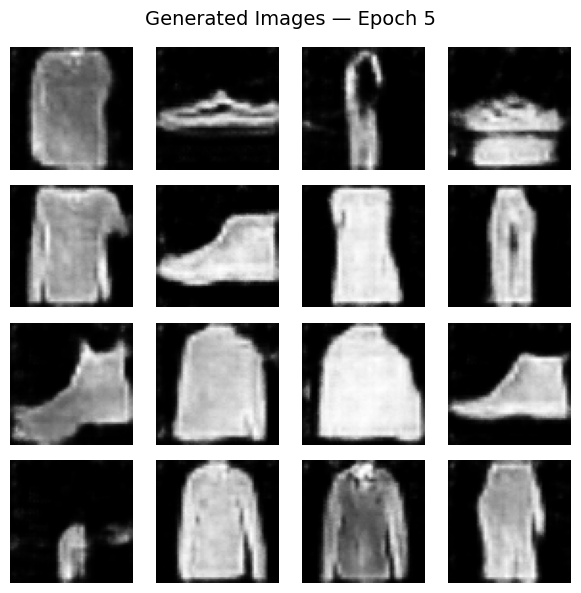

Saved: dcgan_generated/epoch_05.png
Epoch [06/25] | Discriminator Loss: 0.4603 | Generator Loss: 3.7180
Epoch [07/25] | Discriminator Loss: 0.4047 | Generator Loss: 3.7222
Epoch [08/25] | Discriminator Loss: 0.4861 | Generator Loss: 3.6702
Epoch [09/25] | Discriminator Loss: 0.4583 | Generator Loss: 3.5810
Epoch [10/25] | Discriminator Loss: 0.2401 | Generator Loss: 4.3968


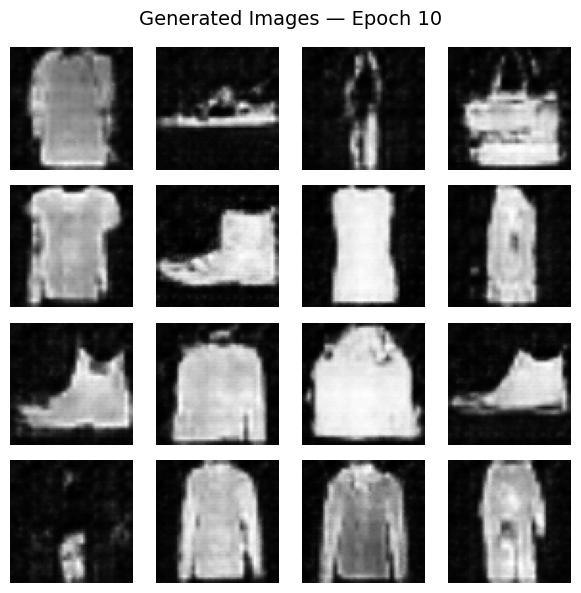

Saved: dcgan_generated/epoch_10.png
Epoch [11/25] | Discriminator Loss: 0.4036 | Generator Loss: 4.0325
Epoch [12/25] | Discriminator Loss: 0.4324 | Generator Loss: 4.0374
Epoch [13/25] | Discriminator Loss: 0.3731 | Generator Loss: 4.1476
Epoch [14/25] | Discriminator Loss: 0.4457 | Generator Loss: 4.0903
Epoch [15/25] | Discriminator Loss: 0.1888 | Generator Loss: 4.9227


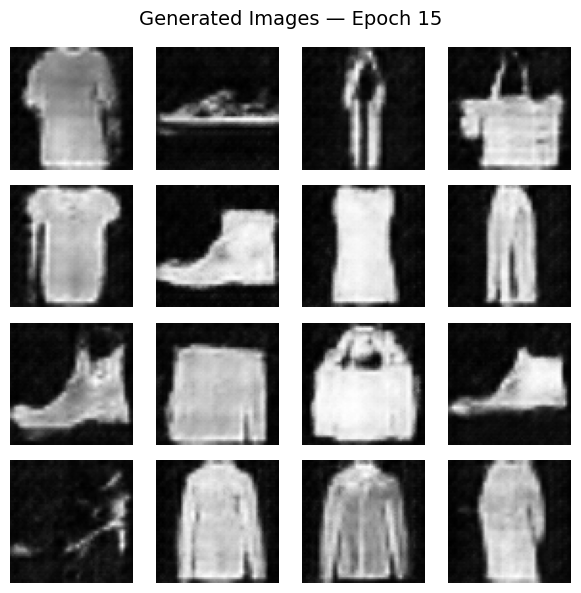

Saved: dcgan_generated/epoch_15.png
Epoch [16/25] | Discriminator Loss: 0.4286 | Generator Loss: 4.2232
Epoch [17/25] | Discriminator Loss: 0.1477 | Generator Loss: 4.8813
Epoch [18/25] | Discriminator Loss: 0.4965 | Generator Loss: 4.1438
Epoch [19/25] | Discriminator Loss: 0.2326 | Generator Loss: 4.6217
Epoch [20/25] | Discriminator Loss: 0.4936 | Generator Loss: 3.9533


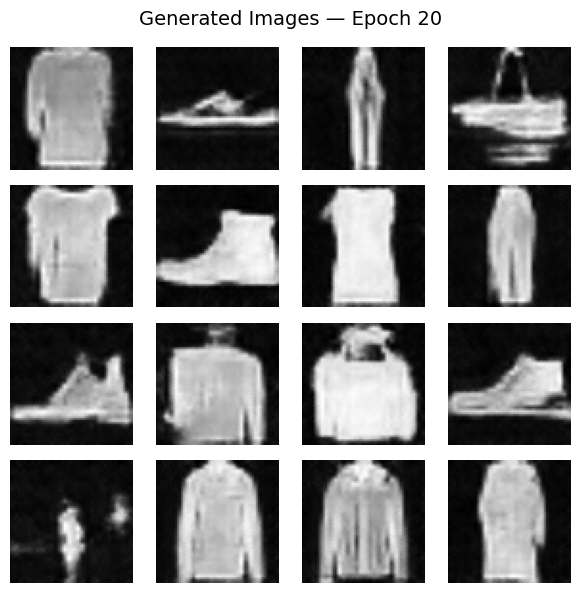

Saved: dcgan_generated/epoch_20.png
Epoch [21/25] | Discriminator Loss: 0.3243 | Generator Loss: 4.1247
Epoch [22/25] | Discriminator Loss: 0.2398 | Generator Loss: 4.9648
Epoch [23/25] | Discriminator Loss: 0.3861 | Generator Loss: 4.5547
Epoch [24/25] | Discriminator Loss: 0.2987 | Generator Loss: 4.4678
Epoch [25/25] | Discriminator Loss: 0.4274 | Generator Loss: 4.1759


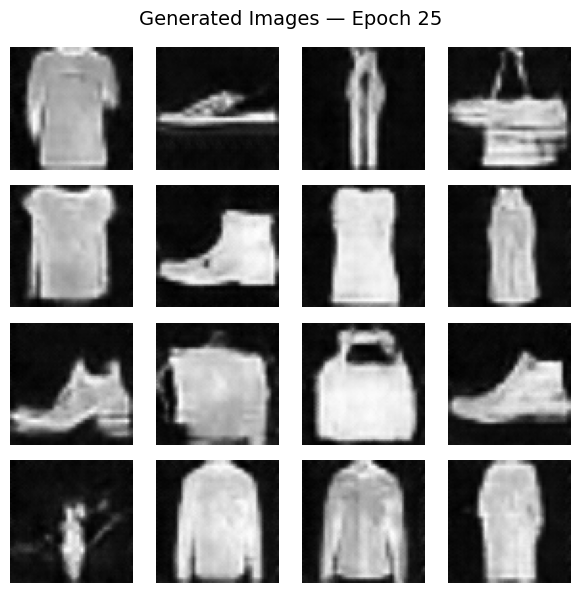

Saved: dcgan_generated/epoch_25.png
DCGAN training completed.


In [12]:
# 15. Train DCGAN for 25 epochs

G_losses = []
D_losses = []

for epoch in range(1, EPOCHS + 1):
    G.train()
    D.train()

    total_G_loss = 0.0
    total_D_loss = 0.0

    for real_images, _ in fashion_loader:
        real_images = real_images.to(device)
        batch_size = real_images.size(0)

        # -------------------------
        # Train Discriminator
        # -------------------------
        D.zero_grad()

        real_labels = torch.ones(batch_size, device=device)
        fake_labels = torch.zeros(batch_size, device=device)

        # Real images
        real_prediction = D(real_images)
        d_loss_real = criterion(real_prediction, real_labels)

        # Fake images
        noise = torch.randn(batch_size, LATENT_DIM, 1, 1, device=device)
        fake_images = G(noise)

        fake_prediction = D(fake_images.detach())
        d_loss_fake = criterion(fake_prediction, fake_labels)

        d_loss = d_loss_real + d_loss_fake
        d_loss.backward()
        optimizer_D.step()

        # -------------------------
        # Train Generator
        # -------------------------
        G.zero_grad()

        # Generator wants fake images to be classified as real = 1
        fake_prediction_for_G = D(fake_images)
        g_loss = criterion(fake_prediction_for_G, real_labels)

        g_loss.backward()
        optimizer_G.step()

        total_D_loss += d_loss.item()
        total_G_loss += g_loss.item()

    avg_D_loss = total_D_loss / len(fashion_loader)
    avg_G_loss = total_G_loss / len(fashion_loader)

    D_losses.append(avg_D_loss)
    G_losses.append(avg_G_loss)

    print(
        f"Epoch [{epoch:02d}/{EPOCHS}] | "
        f"Discriminator Loss: {avg_D_loss:.4f} | "
        f"Generator Loss: {avg_G_loss:.4f}"
    )

    # Save images after every 5 epochs
    if epoch % 5 == 0:
        G.eval()
        with torch.no_grad():
            generated = G(fixed_noise)
        save_grid(generated, epoch)

print("DCGAN training completed.")


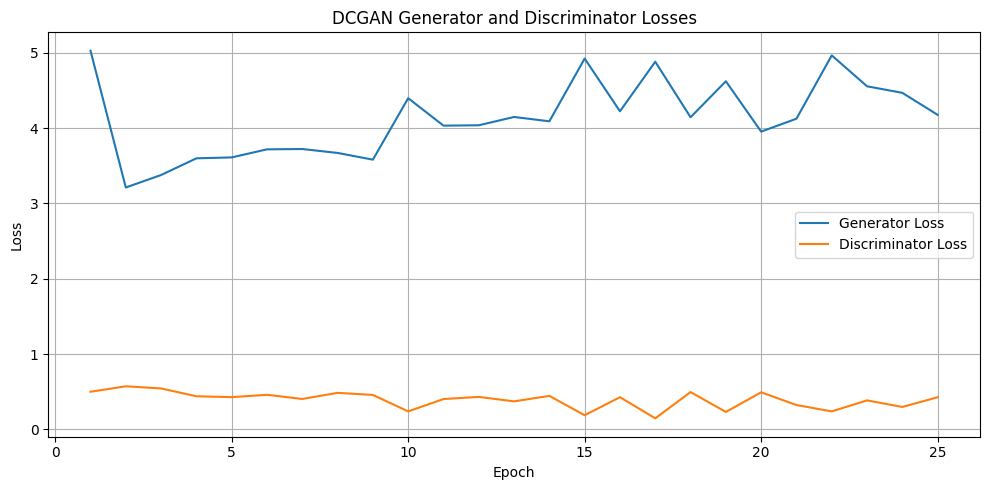

Loss graph saved as dcgan_loss_graph.png


In [13]:
# 16. Plot Generator and Discriminator losses

plt.figure(figsize=(10, 5))
plt.plot(range(1, EPOCHS + 1), G_losses, label="Generator Loss")
plt.plot(range(1, EPOCHS + 1), D_losses, label="Discriminator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DCGAN Generator and Discriminator Losses")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("dcgan_loss_graph.png", dpi=150)
plt.show()

print("Loss graph saved as dcgan_loss_graph.png")


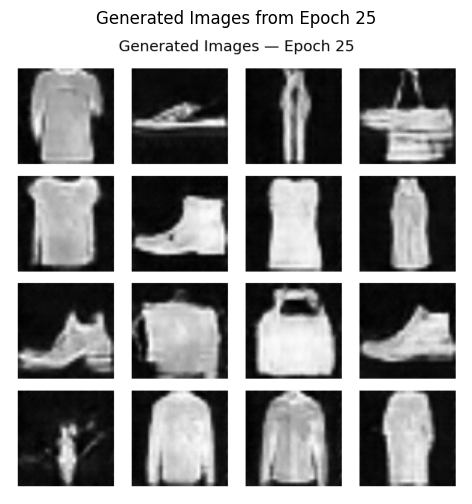

In [14]:
# 17. Generate pictures from a random epoch

# Change this value to 5, 10, 15, 20, or 25
selected_epoch = 25

from PIL import Image

image_path = f"dcgan_generated/epoch_{selected_epoch:02d}.png"

if os.path.exists(image_path):
    img = Image.open(image_path)
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title(f"Generated Images from Epoch {selected_epoch}")
    plt.axis("off")
    plt.show()
else:
    print("Run the training cell first.")


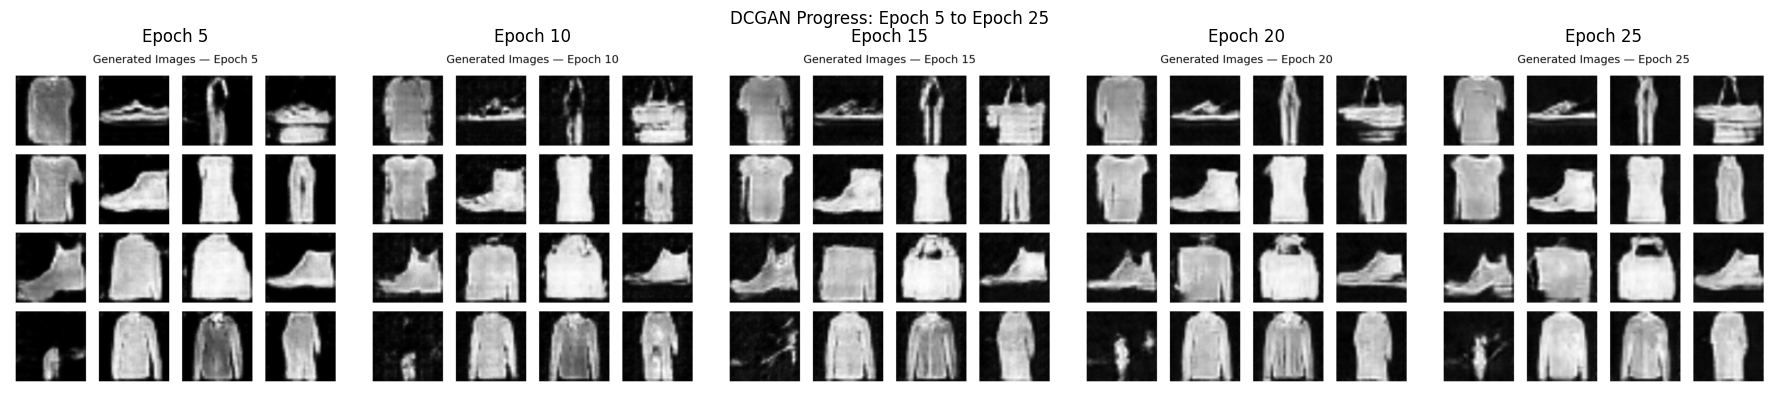

In [15]:
# 18. Display all saved DCGAN grids

from PIL import Image

epochs_to_show = [5, 10, 15, 20, 25]

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for ax, epoch in zip(axes, epochs_to_show):
    path = f"dcgan_generated/epoch_{epoch:02d}.png"
    if os.path.exists(path):
        ax.imshow(Image.open(path))
        ax.set_title(f"Epoch {epoch}")
    else:
        ax.set_title(f"Epoch {epoch}\nNot found")
    ax.axis("off")

plt.suptitle("DCGAN Progress: Epoch 5 to Epoch 25")
plt.tight_layout()
plt.show()


## 19. DCGAN Analysis Answers

### 1. How do the images change from epoch 5 to epoch 25?

At **epoch 5**, the images are usually noisy and unclear. The Generator has only started learning the distribution of clothing images.

At **epoch 10**, basic shapes and silhouettes start appearing.

At **epoch 15**, some images become more recognisable as clothing items such as shoes, shirts, trousers, or bags.

At **epoch 20**, the shapes generally become clearer and more structured.

At **epoch 25**, the Generator normally produces the best images of this run, although they may still be blurry because Fashion-MNIST is a relatively small grayscale dataset.

### 2. Can you observe instability during training?

GAN training can be unstable. The Generator and Discriminator losses may go up and down rather than decrease smoothly. Small oscillations are normal because the two networks continuously compete with each other.

Strong oscillations, sudden image degradation, or many almost-identical generated images can indicate instability or mode collapse.

### 3. At which epoch do cloth-like shapes become recognizable?

A reasonable observation for a typical run is **around epochs 10–15**. The exact epoch depends on the hardware, random seed, optimizer behaviour, and training run.

### 4. Does the GAN keep improving throughout training?

Usually, improvement is strongest during the early and middle epochs. After approximately **20–25 epochs**, visual improvement may slow down. The loss values can continue changing even when the generated image quality has stopped improving significantly.

> **Important:** Use the actual generated grids from your run when writing the final observation. GAN results are not identical in every run.


# Part 2: VAE Practical Demo on MNIST

### Requirements covered
- Import libraries
- Load MNIST
- Display dataset before training
- Build and train a normal Autoencoder (AE) for 15 epochs
- Use Sigmoid activation
- Generate AE latent-space representation
- Implement VAE with encoder, mean and log-variance
- Reparameterization trick
- VAE loss = Reconstruction MSE + KL Divergence
- Train VAE for 20 epochs
- Record reconstruction, KL, and total loss
- Plot losses
- Reconstruct test images
- Show original images on top and reconstructed images on bottom
- Show a compact, coloured VAE latent space
- Generate digits across the latent space
- Generate images from extreme latent points
- Test a point outside the learned latent region


In [16]:
# 20. Import / prepare VAE libraries

import numpy as np
import matplotlib.pyplot as plt

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

MNIST_BATCH_SIZE = 128
LATENT_DIM_VAE = 2
AE_EPOCHS = 15
VAE_EPOCHS = 20

mnist_transform = transforms.ToTensor()

mnist_train = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=mnist_transform
)

mnist_test = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=mnist_transform
)

mnist_train_loader = DataLoader(
    mnist_train,
    batch_size=MNIST_BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

mnist_test_loader = DataLoader(
    mnist_test,
    batch_size=MNIST_BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

print("MNIST train samples:", len(mnist_train))
print("MNIST test samples:", len(mnist_test))


100%|██████████| 9.91M/9.91M [00:00<00:00, 18.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 459kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.21MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.91MB/s]

MNIST train samples: 60000
MNIST test samples: 10000


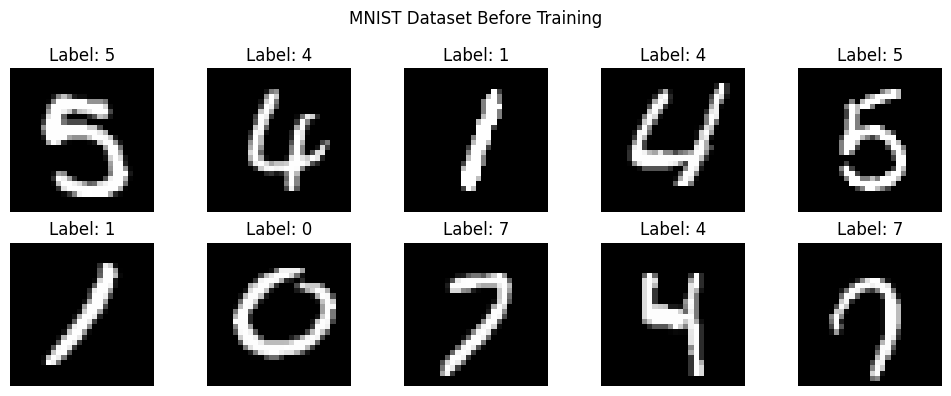

In [17]:
# 21. Display MNIST dataset BEFORE training

images, labels = next(iter(mnist_train_loader))

fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].squeeze(), cmap="gray")
    ax.set_title(f"Label: {labels[i].item()}")
    ax.axis("off")

plt.suptitle("MNIST Dataset Before Training")
plt.tight_layout()
plt.show()


## 22. Normal Autoencoder (AE)

The normal Autoencoder has:

**Encoder:** image → latent vector

**Decoder:** latent vector → reconstructed image

A **Sigmoid** activation is used at the decoder output because MNIST pixels are in the range 0 to 1.


In [18]:
# 23. Normal Autoencoder

class Autoencoder(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim)
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Linear(256, 28 * 28),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        reconstructed = self.decoder(z)
        return reconstructed.view(-1, 1, 28, 28)


ae = Autoencoder(LATENT_DIM_VAE).to(device)
ae_optimizer = optim.Adam(ae.parameters(), lr=0.001)
ae_criterion = nn.MSELoss()

print(ae)


Autoencoder(
  (encoder): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=2, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=784, bias=True)
    (5): Sigmoid()
  )
)


In [19]:
# 24. Train normal Autoencoder for 15 epochs

ae_losses = []

for epoch in range(1, AE_EPOCHS + 1):
    ae.train()
    running_loss = 0.0

    for batch_images, _ in mnist_train_loader:
        batch_images = batch_images.to(device)

        ae_optimizer.zero_grad()

        reconstructed = ae(batch_images)
        loss = ae_criterion(reconstructed, batch_images)

        loss.backward()
        ae_optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(mnist_train_loader)
    ae_losses.append(avg_loss)

    print(f"AE Epoch [{epoch:02d}/{AE_EPOCHS}] | Loss: {avg_loss:.6f}")

print("Autoencoder training completed.")


AE Epoch [01/15] | Loss: 0.061403
AE Epoch [02/15] | Loss: 0.049523
AE Epoch [03/15] | Loss: 0.045914
AE Epoch [04/15] | Loss: 0.043906
AE Epoch [05/15] | Loss: 0.042612
AE Epoch [06/15] | Loss: 0.041716
AE Epoch [07/15] | Loss: 0.041034
AE Epoch [08/15] | Loss: 0.040446
AE Epoch [09/15] | Loss: 0.039944
AE Epoch [10/15] | Loss: 0.039567
AE Epoch [11/15] | Loss: 0.039247
AE Epoch [12/15] | Loss: 0.038917
AE Epoch [13/15] | Loss: 0.038644
AE Epoch [14/15] | Loss: 0.038372
AE Epoch [15/15] | Loss: 0.038161
Autoencoder training completed.


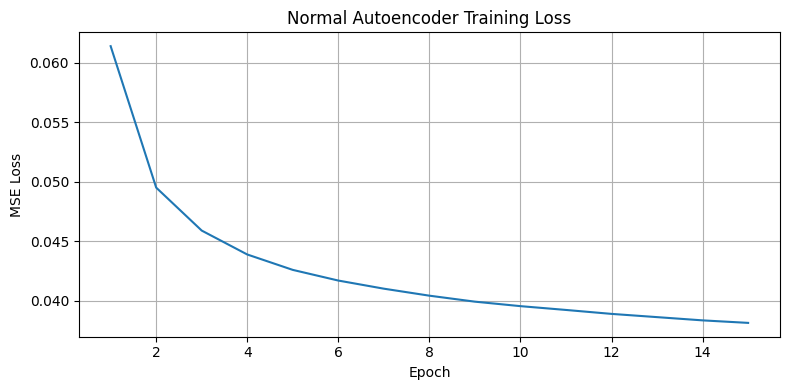

In [20]:
# 25. Plot normal Autoencoder loss

plt.figure(figsize=(8, 4))
plt.plot(range(1, AE_EPOCHS + 1), ae_losses)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Normal Autoencoder Training Loss")
plt.grid(True)
plt.tight_layout()
plt.show()


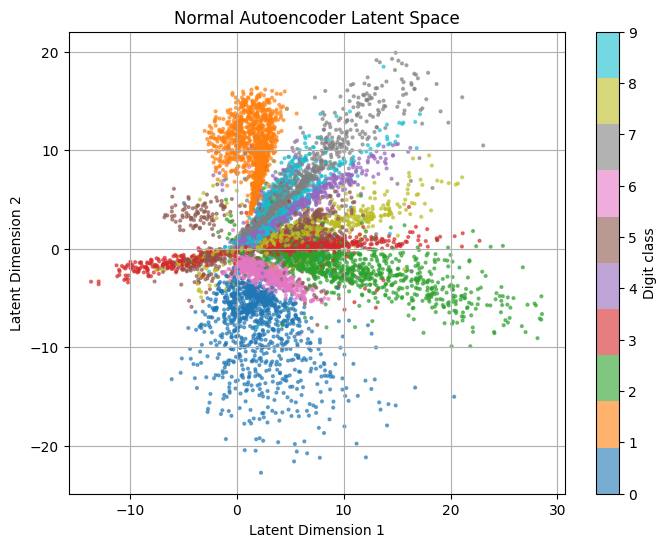

In [21]:
# 26. Generate latent-space representation of normal AE

ae.eval()

latent_points = []
latent_labels = []

with torch.no_grad():
    for batch_images, batch_labels in mnist_test_loader:
        batch_images = batch_images.to(device)
        z = ae.encoder(batch_images)

        latent_points.append(z.cpu().numpy())
        latent_labels.append(batch_labels.numpy())

latent_points = np.concatenate(latent_points)
latent_labels = np.concatenate(latent_labels)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    latent_points[:, 0],
    latent_points[:, 1],
    c=latent_labels,
    cmap="tab10",
    s=4,
    alpha=0.6
)
plt.colorbar(scatter, ticks=range(10), label="Digit class")
plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.title("Normal Autoencoder Latent Space")
plt.grid(True)
plt.show()


## 27. Variational Autoencoder (VAE)

The VAE learns two values for each input:

- **μ (mu):** mean of the latent distribution
- **log σ²:** log variance of the latent distribution

A latent vector is sampled using the **reparameterization trick**:

`z = μ + σ × ε`

where `ε` is random noise sampled from a standard normal distribution.

This regularises the latent space and helps make it smooth and compact.


In [22]:
# 28. VAE architecture

class VAE(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()

        # Encoder
        self.fc1 = nn.Linear(28 * 28, 256)
        self.fc2 = nn.Linear(256, 64)

        # Mean and log-variance
        self.fc_mu = nn.Linear(64, latent_dim)
        self.fc_logvar = nn.Linear(64, latent_dim)

        # Decoder
        self.fc3 = nn.Linear(latent_dim, 64)
        self.fc4 = nn.Linear(64, 256)
        self.fc5 = nn.Linear(256, 28 * 28)

    def encode(self, x):
        x = x.view(x.size(0), -1)
        h = torch.relu(self.fc1(x))
        h = torch.relu(self.fc2(h))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        epsilon = torch.randn_like(std)
        return mu + epsilon * std

    def decode(self, z):
        h = torch.relu(self.fc3(z))
        h = torch.relu(self.fc4(h))
        output = torch.sigmoid(self.fc5(h))
        return output.view(-1, 1, 28, 28)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        reconstructed = self.decode(z)
        return reconstructed, mu, logvar


vae = VAE(LATENT_DIM_VAE).to(device)
vae_optimizer = optim.Adam(vae.parameters(), lr=0.001)

print(vae)


VAE(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=64, bias=True)
  (fc_mu): Linear(in_features=64, out_features=2, bias=True)
  (fc_logvar): Linear(in_features=64, out_features=2, bias=True)
  (fc3): Linear(in_features=2, out_features=64, bias=True)
  (fc4): Linear(in_features=64, out_features=256, bias=True)
  (fc5): Linear(in_features=256, out_features=784, bias=True)
)


## 29. VAE Loss

The VAE uses two main components:

### Reconstruction Loss
Measures how close the reconstructed image is to the original image.

`Reconstruction Loss = MSE(reconstructed, original)`

### KL Divergence
Encourages the learned latent distribution to stay close to a standard normal distribution.

`KL = -0.5 × Σ(1 + logσ² - μ² - σ²)`

### Total Loss

`Total Loss = Reconstruction Loss + KL Divergence`

A compact latent space is useful because nearby latent points can represent similar digits.


In [23]:
# 30. Define VAE loss

def vae_loss_function(reconstructed, original, mu, logvar):
    reconstruction_loss = nn.functional.mse_loss(
        reconstructed,
        original,
        reduction="sum"
    )

    kl_divergence = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    total_loss = reconstruction_loss + kl_divergence

    return total_loss, reconstruction_loss, kl_divergence


In [24]:
# 31. Train VAE for 20 epochs

vae_total_losses = []
vae_reconstruction_losses = []
vae_kl_losses = []

for epoch in range(1, VAE_EPOCHS + 1):
    vae.train()

    total_running = 0.0
    reconstruction_running = 0.0
    kl_running = 0.0

    for batch_images, _ in mnist_train_loader:
        batch_images = batch_images.to(device)

        vae_optimizer.zero_grad()

        reconstructed, mu, logvar = vae(batch_images)

        total_loss, reconstruction_loss, kl_loss = vae_loss_function(
            reconstructed,
            batch_images,
            mu,
            logvar
        )

        total_loss.backward()
        vae_optimizer.step()

        total_running += total_loss.item()
        reconstruction_running += reconstruction_loss.item()
        kl_running += kl_loss.item()

    # Average per training image for easier interpretation
    avg_total = total_running / len(mnist_train)
    avg_reconstruction = reconstruction_running / len(mnist_train)
    avg_kl = kl_running / len(mnist_train)

    vae_total_losses.append(avg_total)
    vae_reconstruction_losses.append(avg_reconstruction)
    vae_kl_losses.append(avg_kl)

    print(
        f"VAE Epoch [{epoch:02d}/{VAE_EPOCHS}] | "
        f"Total: {avg_total:.4f} | "
        f"Reconstruction: {avg_reconstruction:.4f} | "
        f"KL: {avg_kl:.4f}"
    )

print("VAE training completed.")


VAE Epoch [01/20] | Total: 52.1306 | Reconstruction: 50.4917 | KL: 1.6389
VAE Epoch [02/20] | Total: 43.1358 | Reconstruction: 40.0214 | KL: 3.1144
VAE Epoch [03/20] | Total: 41.1830 | Reconstruction: 37.5843 | KL: 3.5988
VAE Epoch [04/20] | Total: 39.9749 | Reconstruction: 36.0842 | KL: 3.8907
VAE Epoch [05/20] | Total: 39.1415 | Reconstruction: 35.0257 | KL: 4.1158
VAE Epoch [06/20] | Total: 38.5059 | Reconstruction: 34.2371 | KL: 4.2689
VAE Epoch [07/20] | Total: 38.0234 | Reconstruction: 33.6267 | KL: 4.3967
VAE Epoch [08/20] | Total: 37.5891 | Reconstruction: 33.0795 | KL: 4.5095
VAE Epoch [09/20] | Total: 37.2569 | Reconstruction: 32.6661 | KL: 4.5908
VAE Epoch [10/20] | Total: 37.0019 | Reconstruction: 32.3418 | KL: 4.6601
VAE Epoch [11/20] | Total: 36.7229 | Reconstruction: 32.0091 | KL: 4.7138
VAE Epoch [12/20] | Total: 36.5236 | Reconstruction: 31.7430 | KL: 4.7807
VAE Epoch [13/20] | Total: 36.3675 | Reconstruction: 31.5554 | KL: 4.8121
VAE Epoch [14/20] | Total: 36.1749 | R

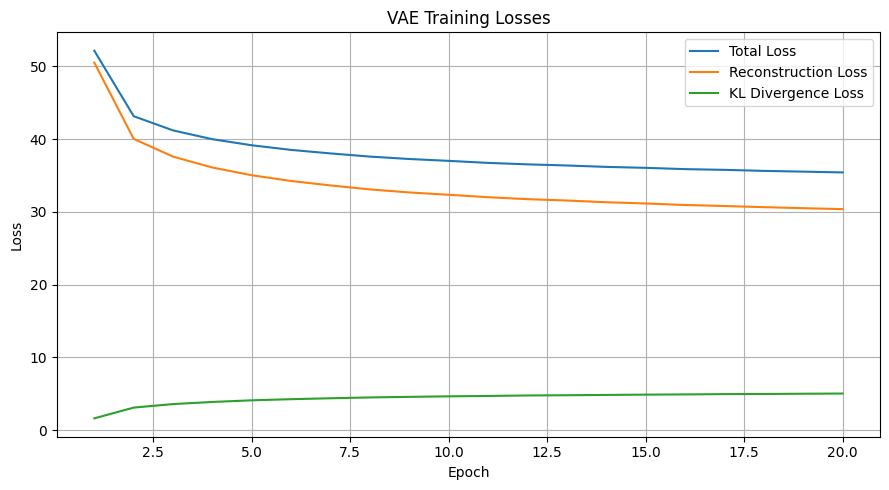

In [25]:
# 32. Plot VAE losses

plt.figure(figsize=(9, 5))
plt.plot(range(1, VAE_EPOCHS + 1), vae_total_losses, label="Total Loss")
plt.plot(range(1, VAE_EPOCHS + 1), vae_reconstruction_losses, label="Reconstruction Loss")
plt.plot(range(1, VAE_EPOCHS + 1), vae_kl_losses, label="KL Divergence Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE Training Losses")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


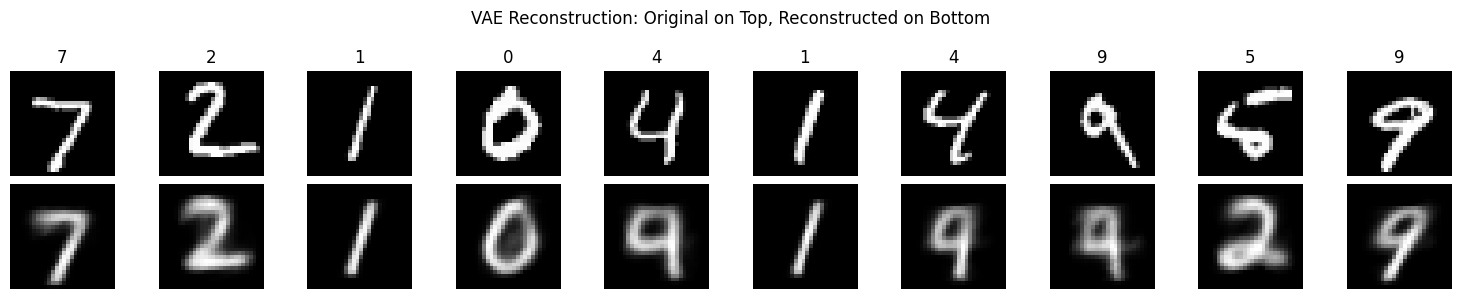

In [26]:
# 33. Reconstruct test images using VAE
# Original images on top, reconstructed images on bottom

vae.eval()

test_images, test_labels = next(iter(mnist_test_loader))
test_images_device = test_images.to(device)

with torch.no_grad():
    reconstructed, _, _ = vae(test_images_device)

fig, axes = plt.subplots(2, 10, figsize=(15, 3))

for i in range(10):
    axes[0, i].imshow(test_images[i].squeeze(), cmap="gray")
    axes[0, i].set_title(str(test_labels[i].item()))
    axes[0, i].axis("off")

    axes[1, i].imshow(reconstructed[i].squeeze().cpu(), cmap="gray")
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("Original", fontsize=11)
axes[1, 0].set_ylabel("VAE Reconstruction", fontsize=11)

plt.suptitle("VAE Reconstruction: Original on Top, Reconstructed on Bottom")
plt.tight_layout()
plt.show()


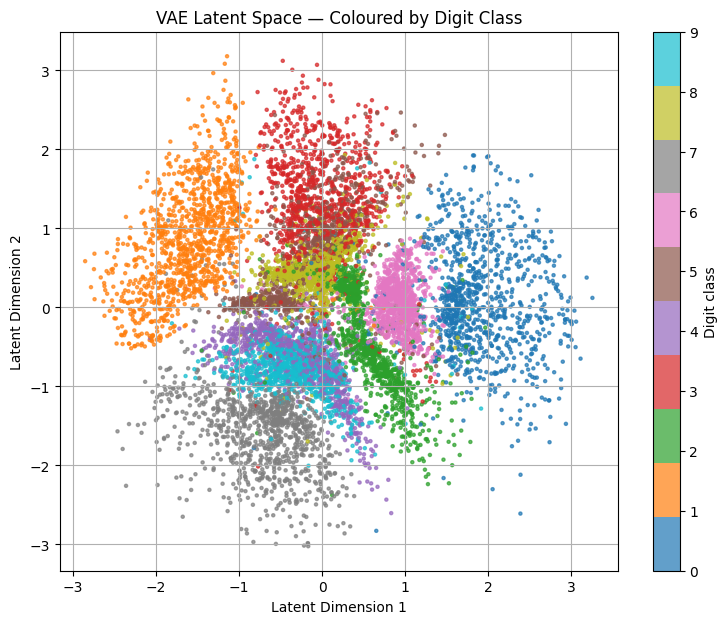

In [27]:
# 34. Show VAE latent space with colors for digit classes

vae.eval()

vae_latent = []
vae_labels = []

with torch.no_grad():
    for batch_images, batch_labels in mnist_test_loader:
        batch_images = batch_images.to(device)

        mu, logvar = vae.encode(batch_images)

        vae_latent.append(mu.cpu().numpy())
        vae_labels.append(batch_labels.numpy())

vae_latent = np.concatenate(vae_latent)
vae_labels = np.concatenate(vae_labels)

plt.figure(figsize=(9, 7))

scatter = plt.scatter(
    vae_latent[:, 0],
    vae_latent[:, 1],
    c=vae_labels,
    cmap="tab10",
    s=5,
    alpha=0.7
)

plt.colorbar(scatter, ticks=range(10), label="Digit class")
plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.title("VAE Latent Space — Coloured by Digit Class")
plt.grid(True)
plt.show()


### Expected VAE latent-space observation

Compared with a normal Autoencoder, the VAE should produce a more continuous and approximately compact latent representation because the KL-divergence term encourages the latent distribution to remain close to a standard normal distribution.

Different digits may form partially separated clusters, but neighbouring regions can also contain transitions between classes.


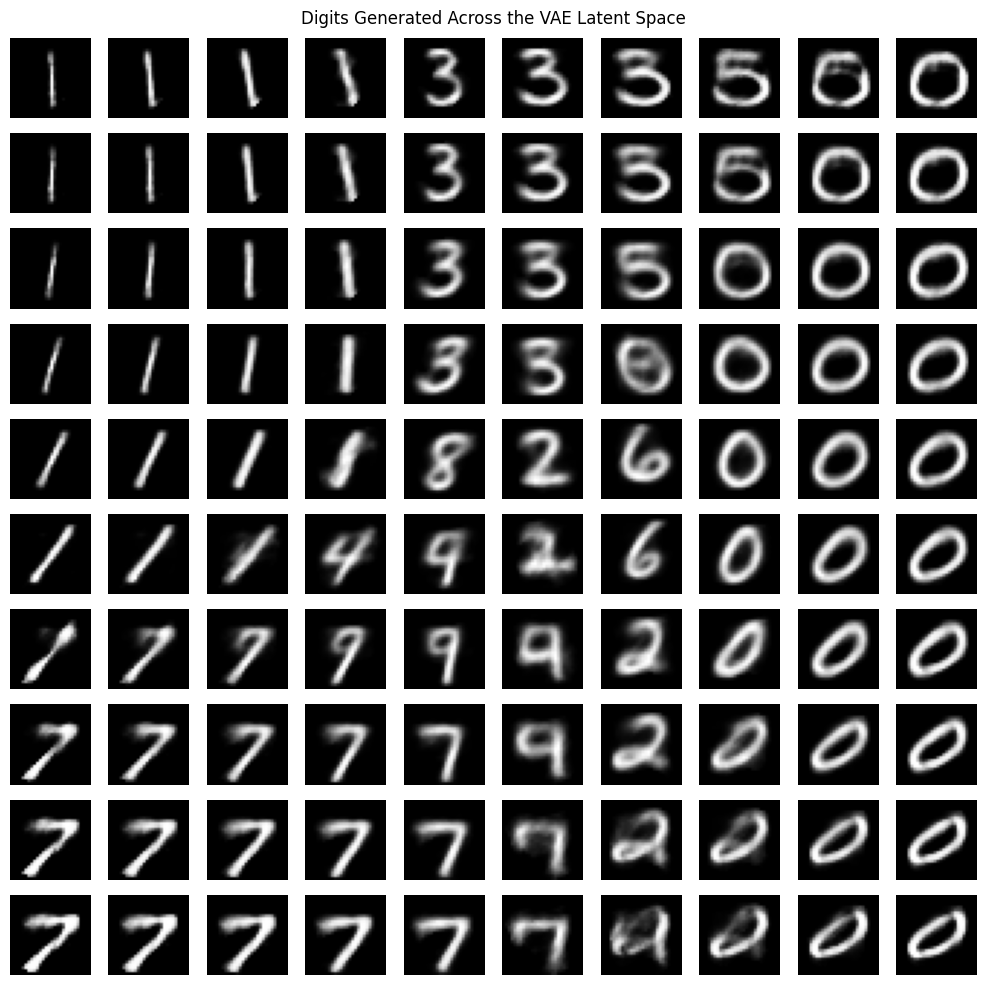

In [28]:
# 35. Generate digits across the latent space

vae.eval()

grid_size = 10
latent_range = 3.0

x_values = np.linspace(-latent_range, latent_range, grid_size)
y_values = np.linspace(-latent_range, latent_range, grid_size)

latent_grid = []

for y in reversed(y_values):
    for x in x_values:
        latent_grid.append([x, y])

latent_grid = torch.tensor(
    latent_grid,
    dtype=torch.float32,
    device=device
)

with torch.no_grad():
    generated_grid = vae.decode(latent_grid).cpu()

fig, axes = plt.subplots(grid_size, grid_size, figsize=(10, 10))

for i, ax in enumerate(axes.flat):
    ax.imshow(generated_grid[i].squeeze(), cmap="gray")
    ax.axis("off")

plt.suptitle("Digits Generated Across the VAE Latent Space")
plt.tight_layout()
plt.show()


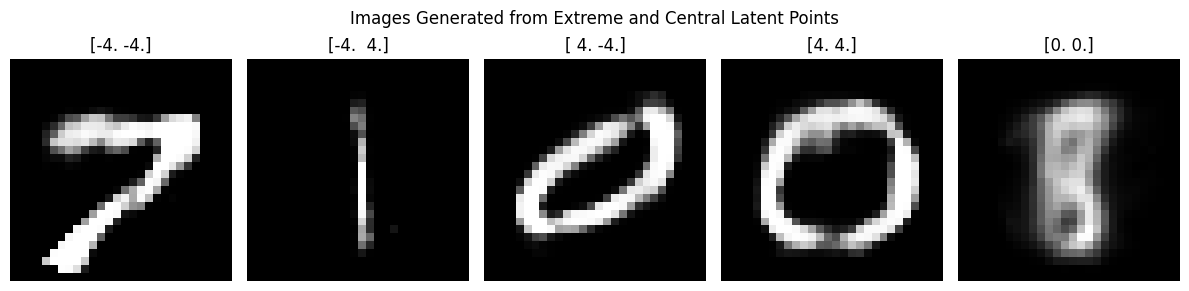

In [29]:
# 36. Generate images from extreme latent points

extreme_points = torch.tensor([
    [-4.0, -4.0],
    [-4.0,  4.0],
    [ 4.0, -4.0],
    [ 4.0,  4.0],
    [ 0.0,  0.0]
], dtype=torch.float32, device=device)

with torch.no_grad():
    extreme_images = vae.decode(extreme_points).cpu()

fig, axes = plt.subplots(1, 5, figsize=(12, 3))

for i, ax in enumerate(axes):
    ax.imshow(extreme_images[i].squeeze(), cmap="gray")
    ax.set_title(str(extreme_points[i].cpu().numpy()))
    ax.axis("off")

plt.suptitle("Images Generated from Extreme and Central Latent Points")
plt.tight_layout()
plt.show()


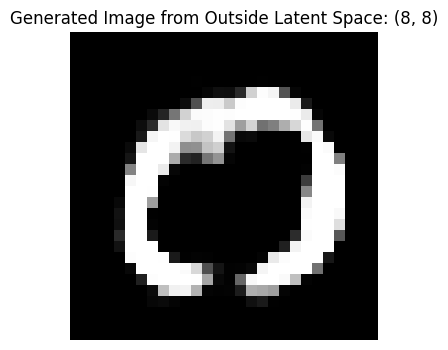

Observation: A point far outside the learned latent region may produce an unclear, unusual, or distorted digit because the Decoder was mainly trained on latent values close to the learned distribution.


In [30]:
# 37. Take a point outside the main latent space

# A point far away from the typical N(0,1)-like region.
outside_point = torch.tensor([[8.0, 8.0]], dtype=torch.float32, device=device)

with torch.no_grad():
    outside_image = vae.decode(outside_point).cpu()

plt.figure(figsize=(4, 4))
plt.imshow(outside_image[0].squeeze(), cmap="gray")
plt.title("Generated Image from Outside Latent Space: (8, 8)")
plt.axis("off")
plt.show()

print(
    "Observation: A point far outside the learned latent region may produce "
    "an unclear, unusual, or distorted digit because the Decoder was mainly "
    "trained on latent values close to the learned distribution."
)


# 38. Final Practical Observations

## DCGAN

The DCGAN starts by generating noise-like images. As the epochs increase, the Generator learns the structure of Fashion-MNIST clothing. Around the middle of training, recognisable clothing-like shapes begin to appear. Later images are generally more structured, although they can remain blurry.

GAN losses are not expected to decrease smoothly. Oscillation is normal because the Generator and Discriminator compete against each other. If many generated images become almost identical, this can indicate **mode collapse**.

Improvement may slow toward the end of training. Therefore, more epochs do not always mean noticeably better images.

## VAE

The normal Autoencoder learns to compress an image into a latent representation and reconstruct it. Its latent space is not explicitly forced to follow a particular probability distribution.

The VAE adds a **KL-divergence** term. This encourages a compact and continuous latent space. Because of this structure, we can sample latent points and generate new digits.

Points near the centre or within the learned latent region usually produce more meaningful digits. Points far outside the learned distribution can produce blurry or unusual outputs.

## Conclusion

The DCGAN and VAE are both generative models, but they work differently:

- **DCGAN:** Generator competes against a Discriminator.
- **VAE:** Encoder and Decoder learn a probabilistic latent representation.
- **DCGAN:** Often produces sharper images but can be unstable.
- **VAE:** Usually gives a smoother and more structured latent space but reconstructions can be blurrier.


# 39. Submission Checklist

## DCGAN
- [x] Import libraries
- [x] Basic parameters
- [x] Hardcoded fixed noise vector
- [x] Fashion-MNIST
- [x] Normalize to -1 to +1
- [x] Generator final activation = Tanh
- [x] Original image displayed
- [x] Generator with transposed convolution
- [x] Generator tested before training
- [x] Discriminator with convolution
- [x] Discriminator output = Sigmoid
- [x] Binary Cross-Entropy
- [x] Generator target = real (1)
- [x] 25 training epochs
- [x] 4 × 4 grids after epochs 5, 10, 15, 20, 25
- [x] Generator and Discriminator losses recorded
- [x] Loss graph
- [x] Analysis questions answered

## VAE
- [x] MNIST loaded and displayed
- [x] Normal Autoencoder
- [x] Sigmoid output
- [x] 15 AE epochs
- [x] AE latent space
- [x] VAE architecture
- [x] Reparameterization trick
- [x] MSE + KL Divergence
- [x] 20 VAE epochs
- [x] Reconstruction, KL and total losses
- [x] Loss graphs
- [x] Test reconstruction
- [x] Coloured latent space
- [x] Latent-space digit generation
- [x] Extreme latent points
- [x] Outside-latent-space experiment
